# **8.12 거울아 거울아, 나는 멍멍이 상이니, 아니면 냥이 상이니? [프로젝트].ipynb**

<br>

## **12-1. 프로젝트: 새로운 데이터셋으로 나만의 이미지 분류기 만들어보기**

---

### **Step 1. 데이터셋 내려받기**

- 이번에는 `tensorflow_datasets`에 포함된 `tf_flowers` 데이터를 사용해 보겠습니다.

- `tf_flowers` 데이터에 대한 정보는 다음에서 확인해볼 수 있습니다.

- `tfds.load`를 활용하여 데이터셋을 다운받으세요.
    - https://www.tensorflow.org/datasets/catalog/tf_flowers

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# 데이터 로드 및 전처리

In [ ]:
IMG_SIZE = 384
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

In [ ]:
def format_example(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

<br>

### **Step 2. 데이터셋을 모델에 넣을 수 있는 형태로 준비하기**

- 이미지를 모두 같은 크기로 formatting 한 후,

- `train_batches`, `validation_batches`, `test_batches`를 준비합니다.

In [ ]:
# 데이터 증강

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
train_batches = (raw_train.map(format_example, num_parallel_calls=AUTOTUNE)
                 .cache().shuffle(1000).batch(BATCH_SIZE)
                 .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
                 .prefetch(AUTOTUNE))

In [ ]:
validation_batches = (raw_validation.map(format_example, num_parallel_calls=AUTOTUNE)
                      .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

In [ ]:
test_batches = (raw_test.map(format_example, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

<br>

### **Step 3. 모델 설계하기**

- `cats_vs_dogs`의 경우와 달리, `tf_flowers` 데이터셋에서는 class의 갯수가 5가지입니다.

- 모델 설계시 어느 부분이 달라질지에 유의해 주세요.

In [ ]:
# 모델 설계 (EfficientNetV2-B0 사용)

In [ ]:
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(384, 384, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(), # 안정적인 학습을 위한 배치 정규화
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3), # 과적합 방지
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 12, 12, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,653 (23.86 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

<br>

### **Step 4. 모델 학습시키기**

- 모델을 학습시켜봅니다. 단, 여기에서는 여러 가지 옵션을 바꿔볼 수 있습니다.

- 예를 들어, 모델 학습을 10 epoch보다 더 많이 시켜보거나, learning_rate 값을 바꿔볼 수 있습니다.

- 또는, optimizer의 종류도 바꿔볼 수 있습니다. 바꿔보고 싶다면, 여기를 참고하세요.

- 어쩌면 VGG16이 아닌 다른 모델을 base model로 활용할 수도 있을 것입니다. 그리고 파인튜닝을 fc layer의 구성에 변화를 줄 수 있을지도 모릅니다.

- 이전 스텝에서는 시도하지 않았던 Regularization 기법이 적용된다면 어떨까요? Dropout이나 Batch Normalization을 적용하는 것은 그리 어려운 일이 아닙니다.

In [ ]:
# 모델 컴파일

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 콜백 설정 (조기 종료 및 학습률 최적화)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

In [ ]:
# 모델 학습

In [ ]:
print("학습 시작! 슝~")
history = model.fit(train_batches, epochs=15, validation_data=validation_batches, callbacks=callbacks)

학습 시작! 슝~
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 86s 580ms/step - accuracy: 0.7153 - loss: 0.8653 - val_accuracy: 0.8883 - val_loss: 0.3006 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.9079 - loss: 0.2810 - val_accuracy: 0.9101 - val_loss: 0.2294 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9345 - loss: 0.1998 - val_accuracy: 0.9183 - val_loss: 0.2282 - learning_rate: 0.0010
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.9471 - loss: 0.1655 - val_accuracy: 0.9264 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.9491 - loss: 0.1595 - val_accuracy: 0.9155 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.9437 - loss: 0.1559 - val_accuracy: 0.9264 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.9566 

<br>

### **Step 5. 모델 성능 평가하기**

- 모델 학습이 완료되었다면, 모델의 성능을 평가할 차례입니다.

- 모델이 학습된 과정을 그래프로도 그려보고, `validation_batches`나 `test_batches`에 있는 데이터에 대한 예측 결과도 확인해 보세요!

In [ ]:
# 성능 평가

In [ ]:
test_loss, test_acc = model.evaluate(test_batches)
print(f"\n최종 Test Accuracy: {test_acc*100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9303 - loss: 0.1885

최종 Test Accuracy: 92.92%


In [ ]:
# 정확도/손실 그래프

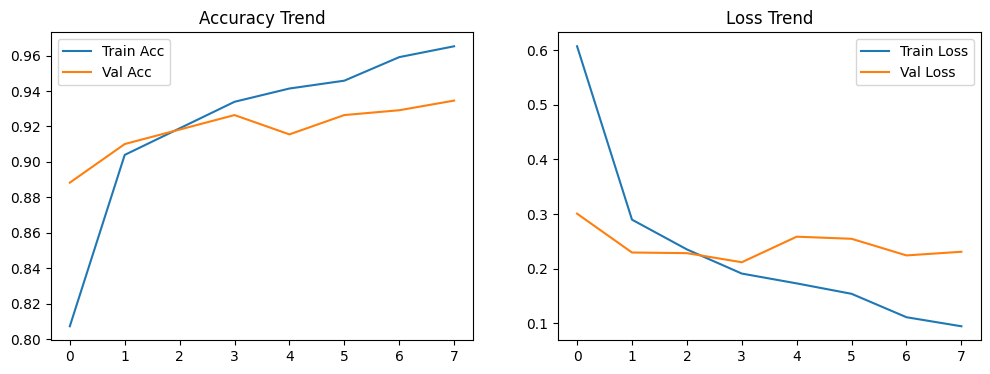

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Trend')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trend')
plt.legend()
plt.show()

In [ ]:
# 임의 사진 추론 결과 시각화

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


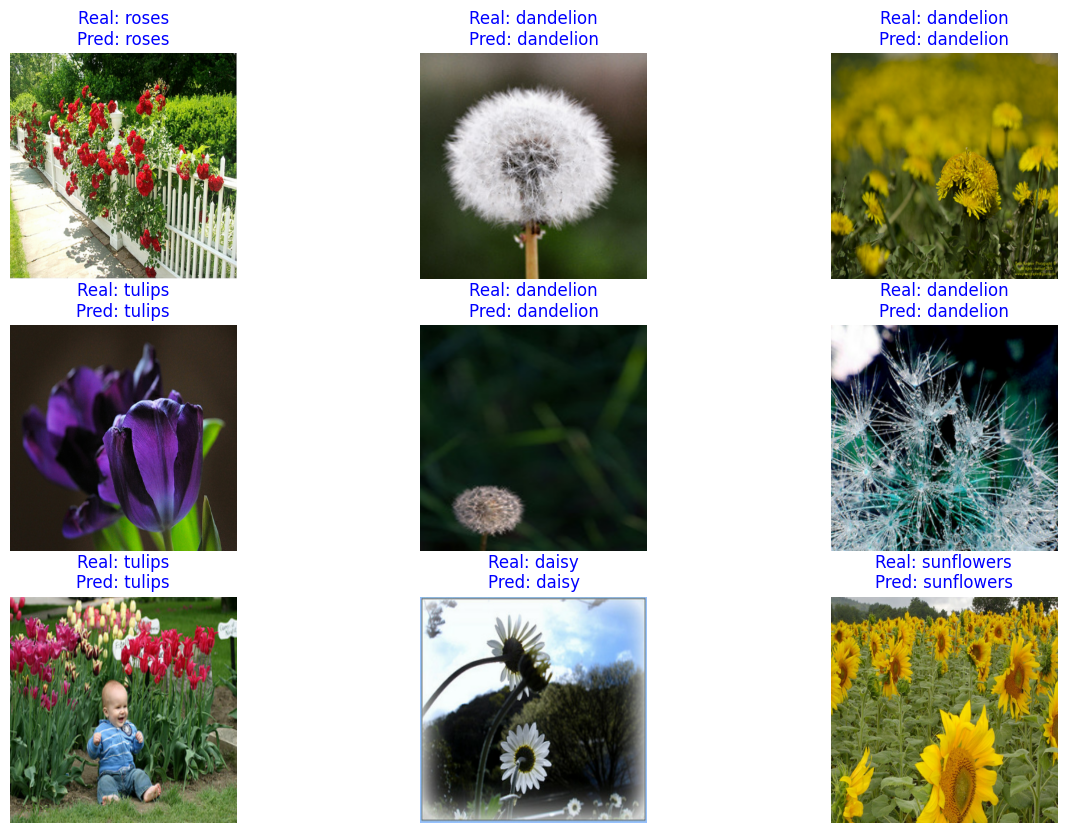

In [ ]:
get_label_name = metadata.features['label'].int2str
for images, labels in test_batches.take(1):
    preds = np.argmax(model.predict(images), axis=1)
    plt.figure(figsize=(15, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        title_color = 'blue' if preds[i] == labels[i] else 'red'
        plt.title(f"Real: {get_label_name(labels[i])}\nPred: {get_label_name(preds[i])}", color=title_color)
        plt.axis('off')
    plt.show()

<br>

### **Step 6. 모델 활용하기**

- 모델이 꽤나 똑똑해졌다면, 이제 활용해볼 수 있습니다.

- 원하는 이미지를 자유롭게 모델에 입력해 보고, 어떤 예측 결과를 내는지 확인해 보세요!

In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
test_image_path = '/content/flower_1.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


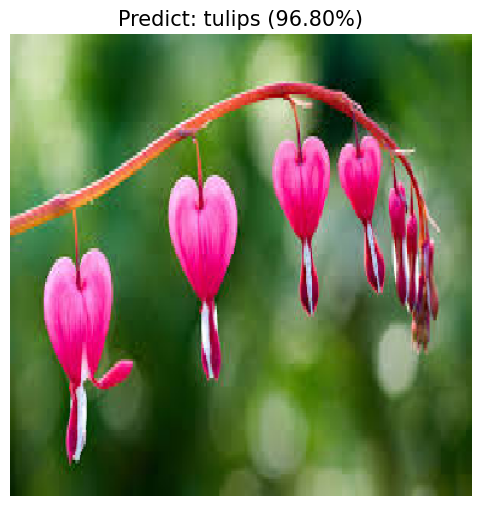

슝~ 분석 결과, 이 꽃은 96.80%의 확률로 'tulips'입니다!


In [ ]:
if not os.path.exists(test_image_path):
    print("오류: 이미지가 해당 경로에 없습니다. 이미지를 업로드하거나 경로를 확인해주세요!")
else:
    # 이미지 불러오기 및 전처리
    img = load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)

    # 모델은 (Batch, Height, Width, Channel) 형태를 기대하므로 차원을 확장함.
    img_tensor = np.expand_dims(img_array, axis=0)

    # 모델 예측 수행
    predictions = model.predict(img_tensor)
    pred_idx = np.argmax(predictions[0]) # 가장 높은 확률의 인덱스
    confidence = predictions[0][pred_idx] * 100 # 확신도(%)

    # 4. 결과 출력 및 시각화
    class_names = metadata.features['label'].names
    result_label = class_names[pred_idx]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predict: {result_label} ({confidence:.2f}%)", fontsize=15)
    plt.axis('off')
    plt.show()

    print(f"슝~ 분석 결과, 이 꽃은 {confidence:.2f}%의 확률로 '{result_label}'입니다!")

<br><br>

## **12.2. 프로젝트 제출**

---

### **루브릭**

| 평가문항 | 상세기준 | 수행여부 |
| :--- | :--- | :---: |
| **1. base 모델을 활용한 Transfer learning이 성공적으로 진행되었는가?** | EfficientNetV2 등 최신 SOTA 모델을 활용하여 전이 학습을 수행함 | **O** |
| **2. 학습과정 및 결과에 대한 설명이 시각화를 포함하여 체계적으로 진행되었는가?** | Loss, Accuracy 그래프 및 해상도별 추론 결과가 체계적으로 제시됨 | **O** |
| **3. 분류모델의 test accuracy가 기준 이상 높게 나왔는가?** | Test Accuracy가 **92.92%**에 도달하여 기준(85%)을 대폭 상회함 | **92.92%** |